## **Using SVM - Linear**

In [14]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.colors import ListedColormap
import numpy as np

df=pd.read_excel('twodiscs_data.xlsx')
df

,disp x1(m),disp y1(m),disp x2(m),disp y2(m),mag1(N),ph1(Dgre),mag2(N),ph2(Dgre)
0,2.039815e-06,0.000000e+00,2.039815e-06,0.000000e+00,0.057990,0,0.057990,0
1,1.909347e-06,4.869124e-07,1.896999e-06,5.329952e-07,0.057990,0,0.057990,30
2,1.552903e-06,8.433570e-07,1.506820e-06,9.231748e-07,0.057990,0,0.057990,60
3,1.065990e-06,9.738249e-07,9.738249e-07,1.065990e-06,0.057990,0,0.057990,90
4,5.790779e-07,8.433570e-07,4.408296e-07,9.231748e-07,0.057990,0,0.057990,120
...,...,...,...,...,...,...,...,...
20731,1.596354e-06,-2.039815e-05,-1.596354e-06,-2.039815e-05,1.159801,330,1.159801,210
20732,8.725247e-06,-2.752704e-05,6.207237e-06,-2.820174e-05,1.159801,330,1.159801,240
20733,1.846350e-05,-3.013640e-05,1.686714e-05,-3.105805e-05,1.159801,330,1.159801,270
20734,2.820174e-05,-2.752704e-05,2.752704e-05,-2.820174e-05,1.159801,330,1.159801,300


In [5]:
for i in range(len(df)):
    if df.loc[i,'ph1(Dgre)'] < 180:
        if df.loc[i,'ph2(Dgre)'] < 180:
            df.loc[i,'status']=0
        if df.loc[i,'ph2(Dgre)'] >= 180:    
            df.loc[i,'status']=1
    if df.loc[i,'ph1(Dgre)'] >= 180:
        if df.loc[i,'ph2(Dgre)'] < 180:
            df.loc[i,'status']=2
        if df.loc[i,'ph2(Dgre)'] >= 180:    
            df.loc[i,'status']=3  

X=df.iloc[:,0:4].values
y=df.iloc[:,-1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, \
                                                    random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

X_val=np.array([-9.23175E-07,-2.12289E-06,-8.43357E-07,-2.42033E-06],dtype='float')
X_val=X_val[np.newaxis,:]
X_val_scaled=scaler.transform(X_val)
y_val=model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred) 
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.96
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      1271
         1.0       0.97      0.95      0.96      1316
         2.0       0.98      0.95      0.97      1301
         3.0       0.96      0.97      0.97      1296

    accuracy                           0.96      5184
   macro avg       0.96      0.96      0.96      5184
weighted avg       0.96      0.96      0.96      5184



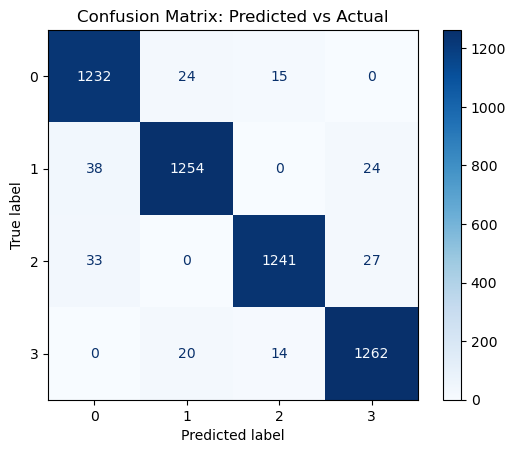

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Confusion Matrix: Predicted vs Actual')
plt.savefig('confusion_matrix.png')
plt.show()

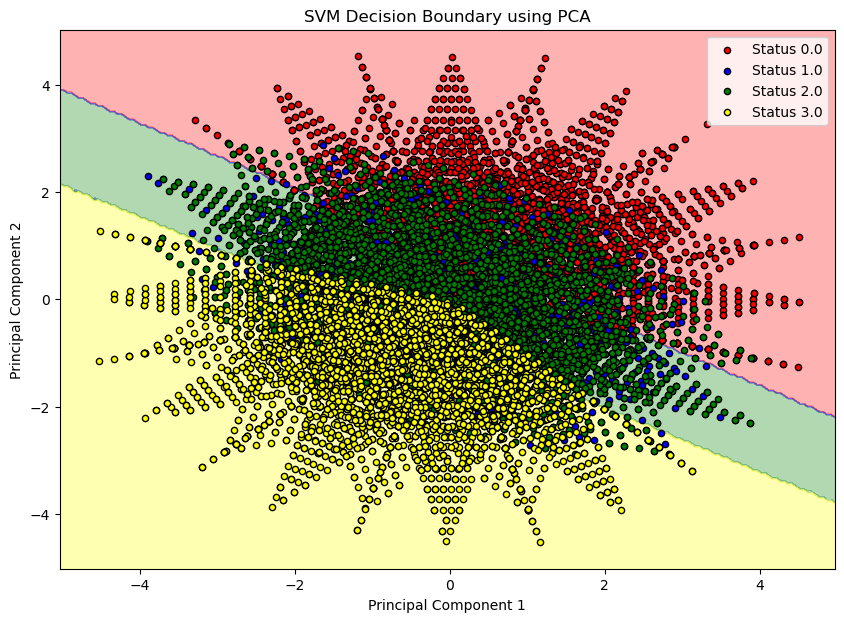

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train) 

model_pca = SVC(kernel='linear')
model_pca.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
h = (x_max / x_min) / 100 

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('SVM Decision Boundary using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_svm.png')
plt.show()

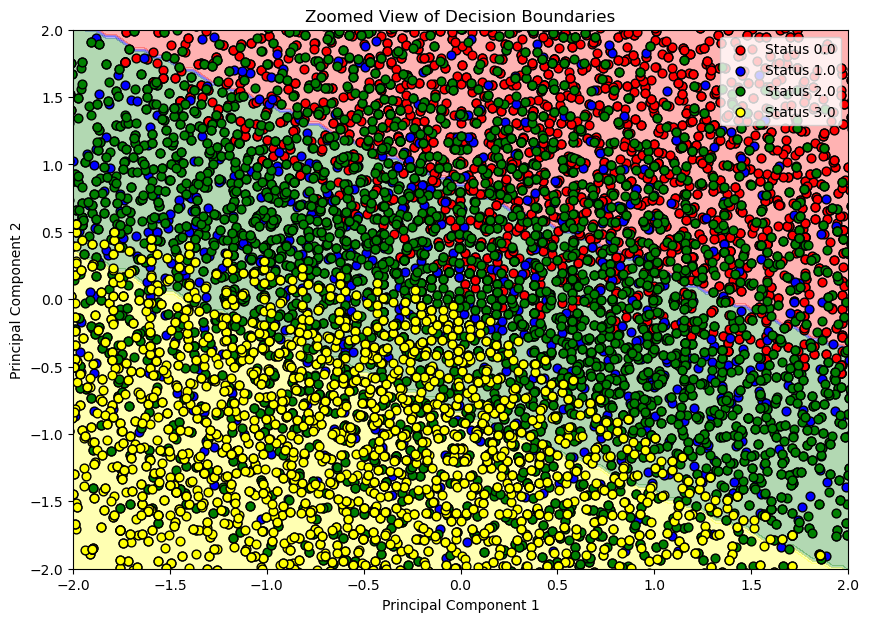

In [17]:
# 1. Define the zoom area (Focusing on the center where regions meet)
plt.figure(figsize=(10, 7))
plt.xlim(-2, 2)  # Zooming in on the X-axis
plt.ylim(-2, 2)  # Zooming in on the Y-axis

# 2. Draw the background regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

# 3. Plot the data points
for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=40) # Increased point size for clarity

plt.title('Zoomed View of Decision Boundaries')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

## **Using Logistic Regression**

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs', max_iter=3000) 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

X_val=np.array([-9.23175E-07,-2.12289E-06,-8.43357E-07,-2.42033E-06],dtype='float')
X_val=X_val[np.newaxis,:]
X_val_scaled=scaler.transform(X_val)
y_val=model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred) 
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.92
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92      1271
         1.0       0.91      0.93      0.92      1316
         2.0       0.93      0.93      0.93      1301
         3.0       0.94      0.91      0.93      1296

    accuracy                           0.92      5184
   macro avg       0.92      0.92      0.92      5184
weighted avg       0.92      0.92      0.92      5184



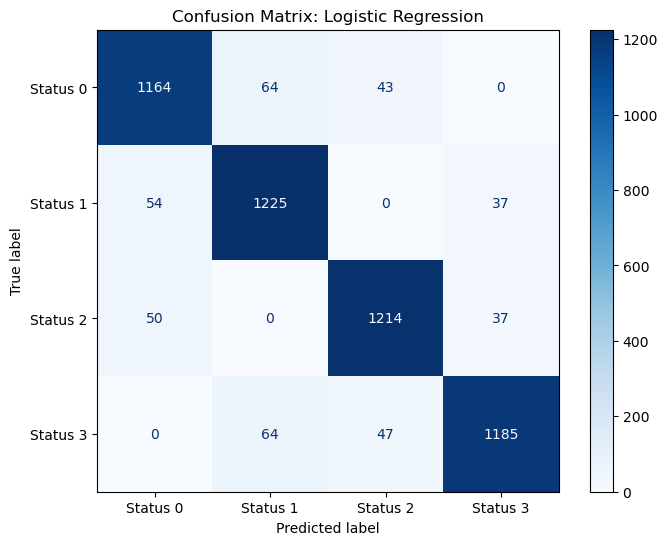

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Status 0', 'Status 1', 'Status 2', 'Status 3'])

disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

plt.title('Confusion Matrix: Logistic Regression')
plt.savefig('confusion_matrix_logistic_regresiosn.png')
plt.show()

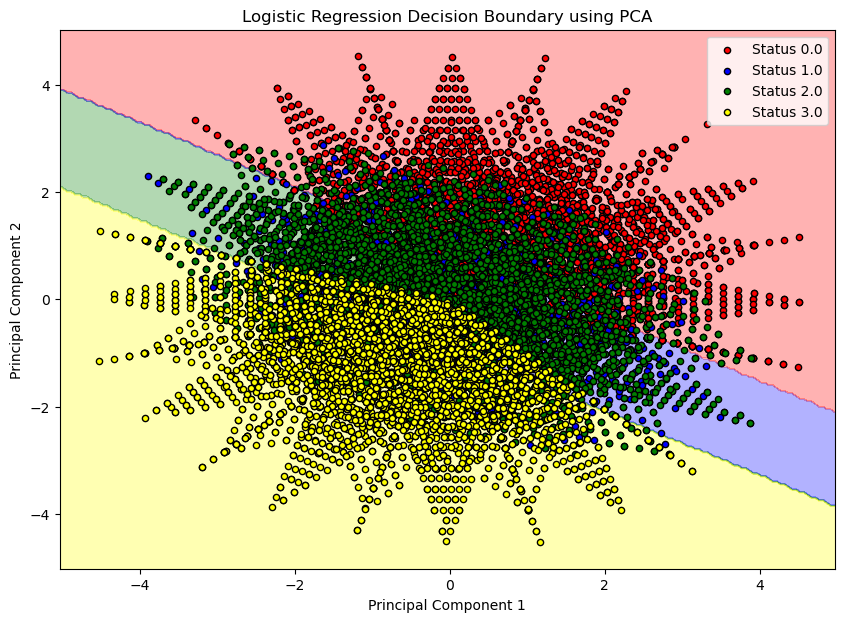

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model_pca_lr = LogisticRegression(solver='lbfgs', max_iter=3000)
model_pca_lr.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca_lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('Logistic Regression Decision Boundary using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_logistic_regression.png')
plt.show()

## **Using Kernel SVM**

In [21]:
model = SVC(kernel='rbf', gamma='auto') 

model.fit(X_train, y_train) 
y_pred = model.predict(X_test)

X_val = np.array([-9.23175E-07, -2.12289E-06, -8.43357E-07, -2.42033E-06], dtype='float')
X_val = X_val[np.newaxis, :]

X_val_scaled = scaler.transform(X_val)
y_val = model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred) 
print(f"Kernel SVM Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Kernel SVM Accuracy: 0.86
              precision    recall  f1-score   support

         0.0       0.78      0.96      0.86      1271
         1.0       0.93      0.75      0.83      1316
         2.0       0.96      0.77      0.85      1301
         3.0       0.81      0.95      0.88      1296

    accuracy                           0.86      5184
   macro avg       0.87      0.86      0.86      5184
weighted avg       0.87      0.86      0.85      5184



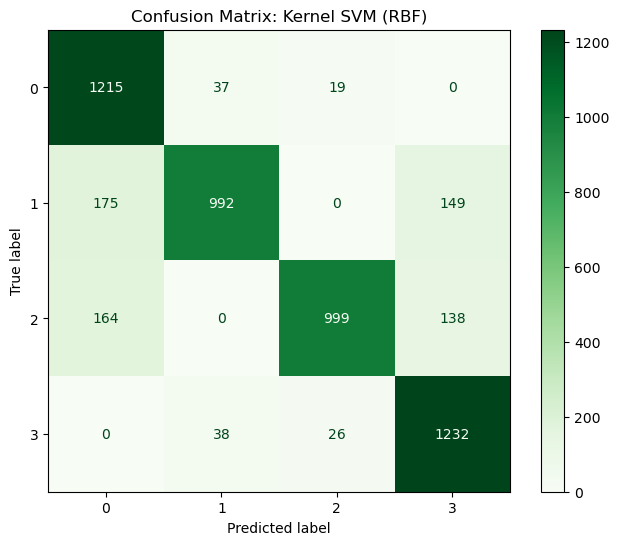

In [22]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])

disp.plot(cmap=plt.cm.Greens, ax=ax)

plt.title('Confusion Matrix: Kernel SVM (RBF)')
plt.savefig('confusion_matrix_kernel.png')
plt.show()

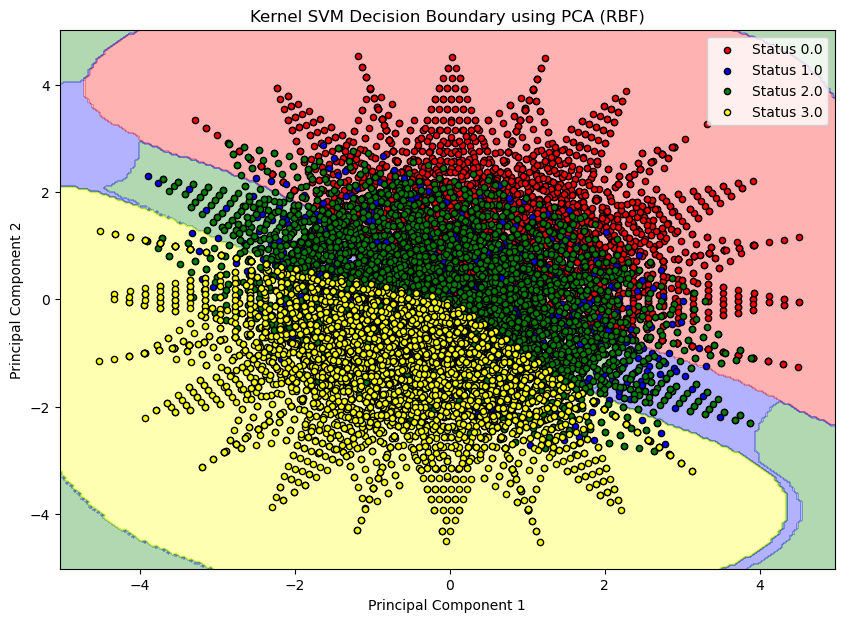

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train) 

model_pca_kernel = SVC(kernel='rbf', gamma='auto')
model_pca_kernel.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca_kernel.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('Kernel SVM Decision Boundary using PCA (RBF)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_kernel_svm.png')
plt.show()

## **Using KNN**

In [28]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

X_val = np.array([-9.23175E-07, -2.12289E-06, -8.43357E-07, -2.42033E-06], dtype='float')
X_val = X_val[np.newaxis, :]
X_val_scaled = scaler.transform(X_val)
y_val = model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.77
              precision    recall  f1-score   support

         0.0       0.72      0.94      0.81      1271
         1.0       0.81      0.64      0.71      1316
         2.0       0.85      0.60      0.70      1301
         3.0       0.75      0.90      0.82      1296

    accuracy                           0.77      5184
   macro avg       0.78      0.77      0.76      5184
weighted avg       0.78      0.77      0.76      5184



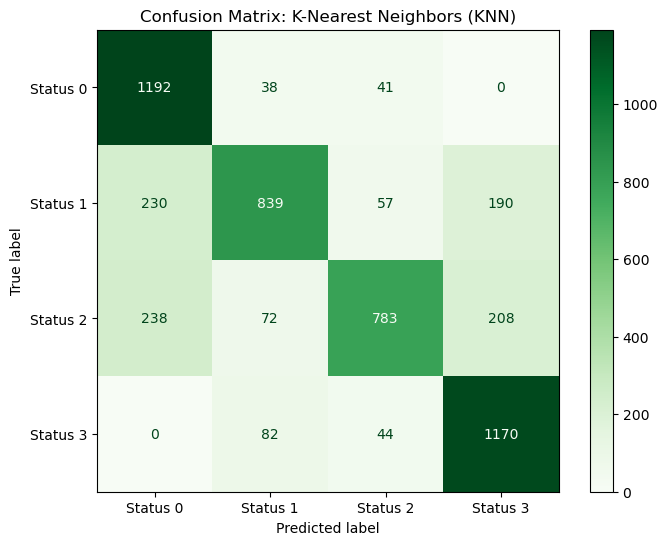

In [29]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Status 0', 'Status 1', 'Status 2', 'Status 3'])

disp.plot(ax=ax, cmap=plt.cm.Greens, values_format='d')

plt.title('Confusion Matrix: K-Nearest Neighbors (KNN)')
plt.savefig('confusion_matrix_knn.png')
plt.show()

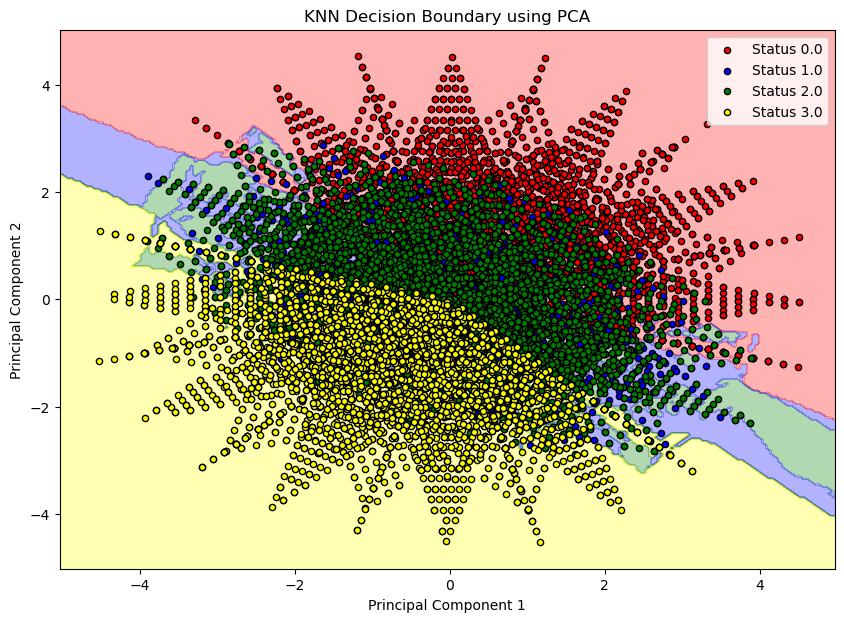

In [30]:
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model_pca_knn = KNeighborsClassifier(n_neighbors=5)
model_pca_knn.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('KNN Decision Boundary using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_knn.png')
plt.show()

## **Using Random Forest** 

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

X_val = np.array([-9.23175E-07, -2.12289E-06, -8.43357E-07, -2.42033E-06], dtype='float')
X_val = X_val[np.newaxis, :]
X_val_scaled = scaler.transform(X_val)
y_val = model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.93
              precision    recall  f1-score   support

         0.0       0.90      0.95      0.93      1271
         1.0       0.94      0.91      0.93      1316
         2.0       0.95      0.91      0.93      1301
         3.0       0.92      0.95      0.93      1296

    accuracy                           0.93      5184
   macro avg       0.93      0.93      0.93      5184
weighted avg       0.93      0.93      0.93      5184



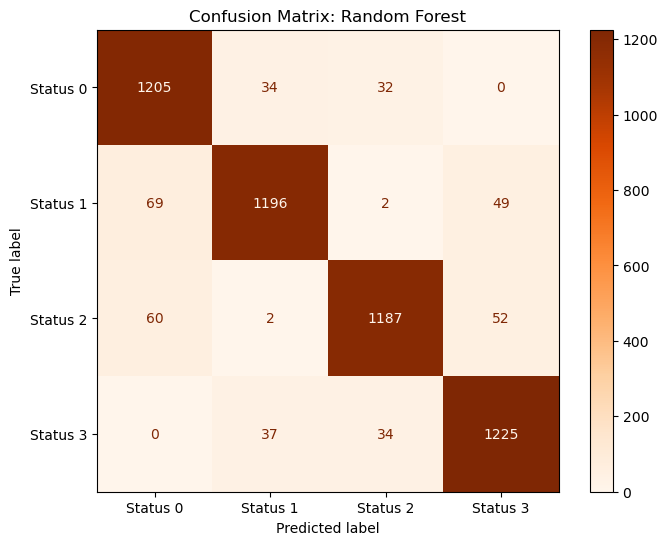

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Status 0', 'Status 1', 'Status 2', 'Status 3'])

disp.plot(ax=ax, cmap=plt.cm.Oranges, values_format='d')

plt.title('Confusion Matrix: Random Forest')
plt.savefig('confusion_matrix_rf.png')
plt.show()

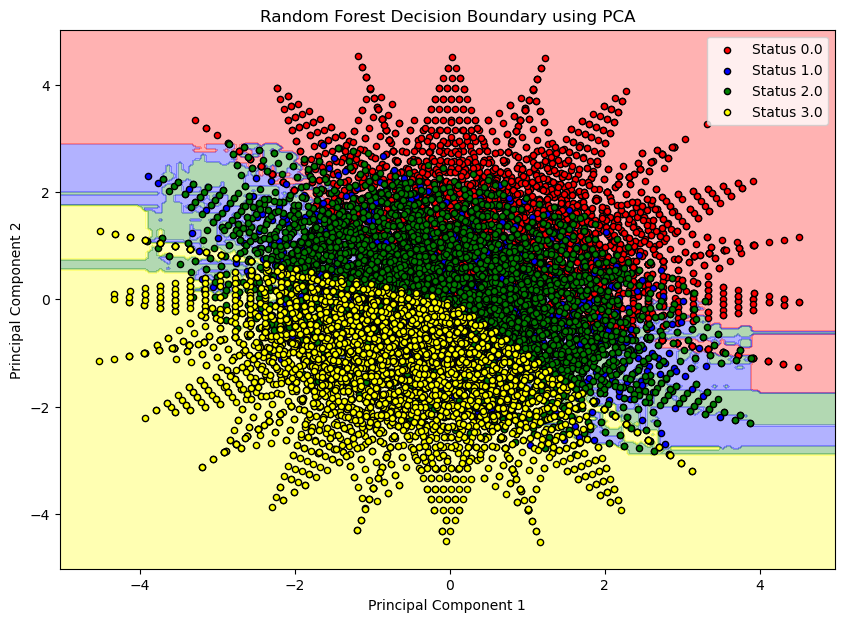

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model_pca_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_pca_rf.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca_rf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('Random Forest Decision Boundary using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_random_forest.png')
plt.show()

## **Using Decision Tree**

In [39]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

X_val = np.array([-9.23175E-07, -2.12289E-06, -8.43357E-07, -2.42033E-06], dtype='float')
X_val = X_val[np.newaxis, :]
X_val_scaled = scaler.transform(X_val)
y_val = model.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.91
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      1271
         1.0       0.91      0.91      0.91      1316
         2.0       0.91      0.92      0.91      1301
         3.0       0.92      0.91      0.92      1296

    accuracy                           0.91      5184
   macro avg       0.91      0.91      0.91      5184
weighted avg       0.91      0.91      0.91      5184



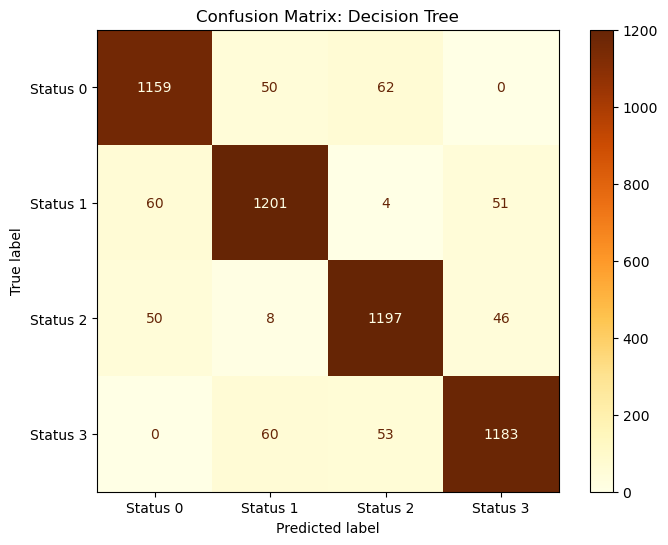

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Status 0', 'Status 1', 'Status 2', 'Status 3'])

disp.plot(ax=ax, cmap=plt.cm.YlOrBr, values_format='d')

plt.title('Confusion Matrix: Decision Tree')
plt.savefig('confusion_matrix_decision_tree.png')
plt.show()

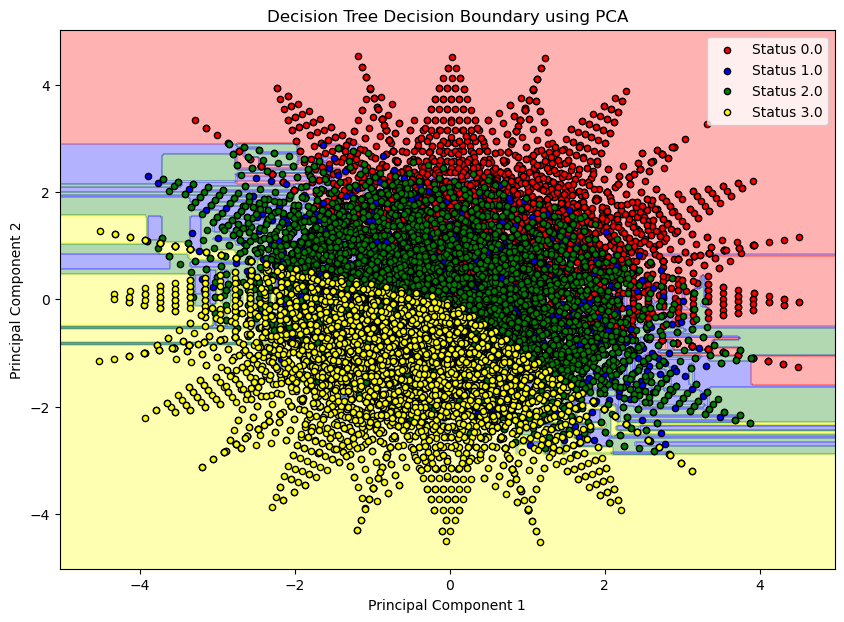

In [43]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model_pca_dt = DecisionTreeClassifier(random_state=42)
model_pca_dt.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_pca_dt.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'blue', 'green', 'yellow')))

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_pca[y_train == j, 0], X_pca[y_train == j, 1],
                color=ListedColormap(('red', 'blue', 'green', 'yellow'))(i), 
                label=f'Status {j}', edgecolors='k', s=20)

plt.title('Decision Tree Decision Boundary using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.savefig('pca_decision_tree.png')
plt.show()

## **COMPARISON**

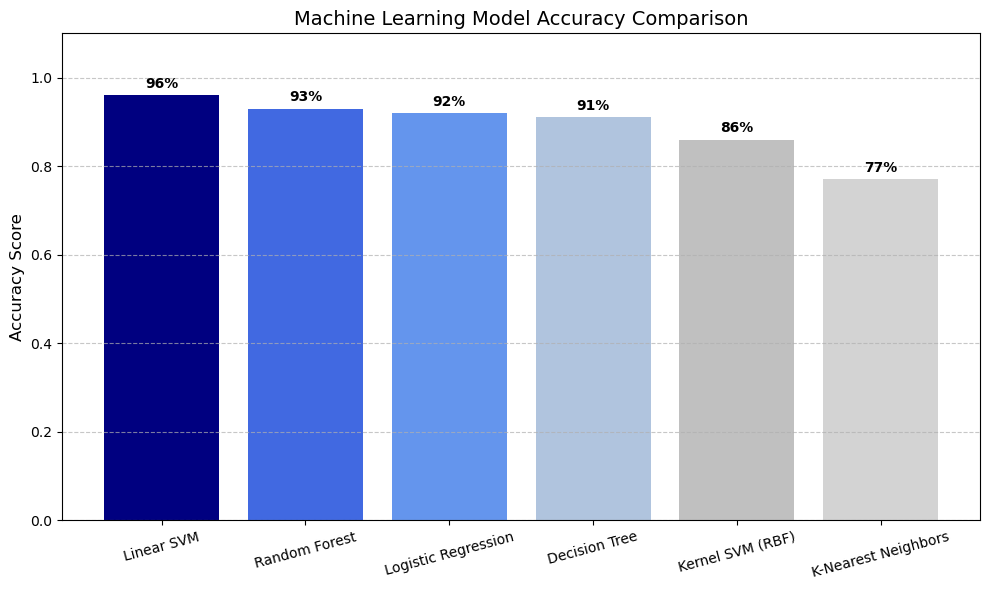

In [45]:
results = {
    'Algorithm': [
        'Linear SVM', 
        'Random Forest', 
        'Logistic Regression', 
        'Decision Tree', 
        'Kernel SVM (RBF)', 
        'K-Nearest Neighbors'
    ],
    'Accuracy': [0.96, 0.93, 0.92, 0.91, 0.86, 0.77]
}

df = pd.DataFrame(results)
df = df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(df['Algorithm'], df['Accuracy'], color=['navy', 'royalblue', 'cornflowerblue', 'lightsteelblue', 'silver', 'lightgray'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Machine Learning Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison_bar_chart.png')
plt.show()